# 04 - Statistical Analysis and Visualization

This notebook performs the final analysis of:

- Baseline models
- Optimized models

The notebook includes:
- statistical analysis
- boxplots
- rankings
- convergence analysis
- prediction visualization
- comparison tables
- significance testing

This notebook generates the final results for the article.

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare

import scikit_posthocs as sp

In [2]:
BASE_DIR = "/home/jovyan/work"

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
baseline_results_path = os.path.join(
    RESULTS_DIR,
    "baseline_results.csv"
)

baseline_df = pd.read_csv(
    baseline_results_path
)

baseline_df.head()

,Model,Seed,Test_MAE,Test_RMSE,Test_R2,Daylight_MAE,Daylight_RMSE,Daylight_R2,Training_Time_Seconds,Epochs
0,MLP,0,65.665880,113.645421,0.913334,127.945665,159.848603,0.767744,13.806466,21
1,MLP,1,66.528532,115.869645,0.909909,126.497070,162.227761,0.760779,21.904707,44
2,MLP,2,75.782521,122.259362,0.899699,140.049666,171.964127,0.731202,12.035300,23
3,MLP,3,62.642823,109.424723,0.919652,120.569489,153.734586,0.785171,20.891664,41
4,MLP,4,66.673266,113.443079,0.913643,123.137229,159.017096,0.770154,14.908950,27


In [4]:
optimized_results_path = os.path.join(
    RESULTS_DIR,
    "final_optimized_results.csv"
)

optimized_df = pd.read_csv(
    optimized_results_path
)

optimized_df.head()

,Optimizer,Test_MAE,Test_RMSE,Test_R2,Daylight_MAE,Daylight_RMSE,Daylight_R2,Training_Time_Seconds,Epochs,units_1,units_2,dropout_rate,learning_rate,batch_size
0,PSO,57.337343,111.660989,0.916335,107.462846,154.938887,0.781792,49.626996,20,81,58,0.190421,0.003177,64
1,GA,58.759426,113.954042,0.912863,112.801450,158.315735,0.772177,52.146689,19,78,30,0.100000,0.003319,64


In [5]:
baseline_summary = baseline_df.groupby("Model").agg({

    "Test_MAE": ["mean", "std"],
    "Test_RMSE": ["mean", "std"],
    "Test_R2": ["mean", "std"],

    "Daylight_MAE": ["mean", "std"],
    "Daylight_RMSE": ["mean", "std"],
    "Daylight_R2": ["mean", "std"]

})

baseline_summary

Test_MAE             Test_RMSE             Test_R2            \
            mean       std        mean       std      mean       std   
Model                                                                  
CNN1D  73.783715  4.681709  123.282739  6.419694  0.897791  0.010608   
GRU    63.765284  4.543839  112.108240  4.164174  0.915570  0.006134   
LSTM   69.569351  5.957919  114.623569  4.595352  0.911723  0.007027   
MLP    67.458604  4.928869  114.928446  4.710934  0.911247  0.007347   

      Daylight_MAE            Daylight_RMSE            Daylight_R2            
              mean        std          mean        std        mean       std  
Model                                                                         
CNN1D   141.631108  11.209182    172.482261  10.645399    0.728756  0.033296  
GRU     117.052837  11.350561    156.011823   6.878480    0.778415  0.019048  
LSTM    115.750315  12.745650    156.484603   8.602835    0.776878  0.024305  
MLP     127.639824   7.511102    161.358434   6.691804    0.763010  0.019883

In [6]:
baseline_summary_path = os.path.join(
    TABLES_DIR,
    "baseline_summary.csv"
)

baseline_summary.to_csv(
    baseline_summary_path
)

print("Saved:", baseline_summary_path)

Saved: /home/jovyan/work/outputs/tables/baseline_summary.csv


In [7]:
optimized_summary = optimized_df.groupby("Optimizer").agg({

    "Test_MAE": ["mean", "std"],
    "Test_RMSE": ["mean", "std"],
    "Test_R2": ["mean", "std"],

    "Daylight_MAE": ["mean", "std"],
    "Daylight_RMSE": ["mean", "std"],
    "Daylight_R2": ["mean", "std"]

})

optimized_summary

Test_MAE       Test_RMSE       Test_R2     Daylight_MAE      \
                mean std        mean std      mean std         mean std   
Optimizer                                                                 
GA         58.759426 NaN  113.954042 NaN  0.912863 NaN   112.801450 NaN   
PSO        57.337343 NaN  111.660989 NaN  0.916335 NaN   107.462846 NaN   

          Daylight_RMSE     Daylight_R2      
                   mean std        mean std  
Optimizer                                    
GA           158.315735 NaN    0.772177 NaN  
PSO          154.938887 NaN    0.781792 NaN

In [8]:
optimized_summary_path = os.path.join(
    TABLES_DIR,
    "optimized_summary.csv"
)

optimized_summary.to_csv(
    optimized_summary_path
)

print("Saved:", optimized_summary_path)

Saved: /home/jovyan/work/outputs/tables/optimized_summary.csv


<Figure size 1000x500 with 0 Axes>

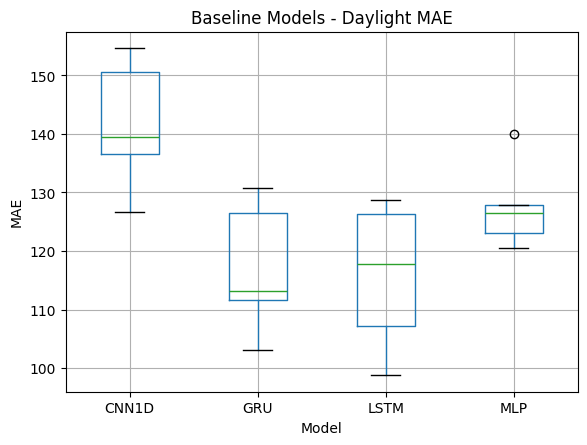

Saved: /home/jovyan/work/outputs/figures/baseline_boxplot_mae.png


In [9]:
plt.figure(figsize=(10,5))

baseline_df.boxplot(
    column="Daylight_MAE",
    by="Model"
)

plt.title("Baseline Models - Daylight MAE")
plt.suptitle("")

plt.ylabel("MAE")
plt.grid(True)

baseline_boxplot_path = os.path.join(
    FIGURES_DIR,
    "baseline_boxplot_mae.png"
)

plt.savefig(
    baseline_boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", baseline_boxplot_path)

<Figure size 1000x500 with 0 Axes>

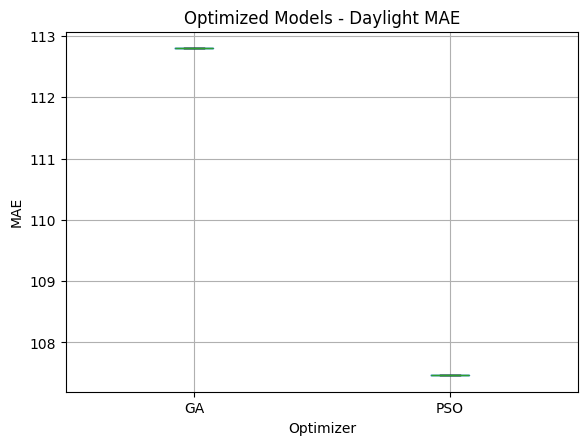

Saved: /home/jovyan/work/outputs/figures/optimized_boxplot_mae.png


In [10]:
plt.figure(figsize=(10,5))

optimized_df.boxplot(
    column="Daylight_MAE",
    by="Optimizer"
)

plt.title("Optimized Models - Daylight MAE")
plt.suptitle("")

plt.ylabel("MAE")
plt.grid(True)

optimized_boxplot_path = os.path.join(
    FIGURES_DIR,
    "optimized_boxplot_mae.png"
)

plt.savefig(
    optimized_boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", optimized_boxplot_path)

In [11]:
baseline_ranking = baseline_df.groupby("Model")["Daylight_MAE"].mean()

baseline_ranking = baseline_ranking.sort_values()

baseline_ranking

Model
LSTM     115.750315
GRU      117.052837
MLP      127.639824
CNN1D    141.631108
Name: Daylight_MAE, dtype: float64

In [12]:
optimized_ranking = optimized_df.groupby("Optimizer")["Daylight_MAE"].mean()

optimized_ranking = optimized_ranking.sort_values()

optimized_ranking

Optimizer
PSO    107.462846
GA     112.801450
Name: Daylight_MAE, dtype: float64

In [13]:
combined_results = []

for _, row in baseline_df.iterrows():

    combined_results.append({
        "Method": row["Model"],
        "Type": "Baseline",
        "Daylight_MAE": row["Daylight_MAE"]
    })

for _, row in optimized_df.iterrows():

    combined_results.append({
        "Method": row["Optimizer"],
        "Type": "Optimized",
        "Daylight_MAE": row["Daylight_MAE"]
    })

combined_df = pd.DataFrame(combined_results)

combined_df.tail()

,Method,Type,Daylight_MAE
17,GRU,Baseline,111.713451
18,GRU,Baseline,113.175834
19,GRU,Baseline,126.506294
20,PSO,Optimized,107.462846
21,GA,Optimized,112.801450


<Figure size 1200x500 with 0 Axes>

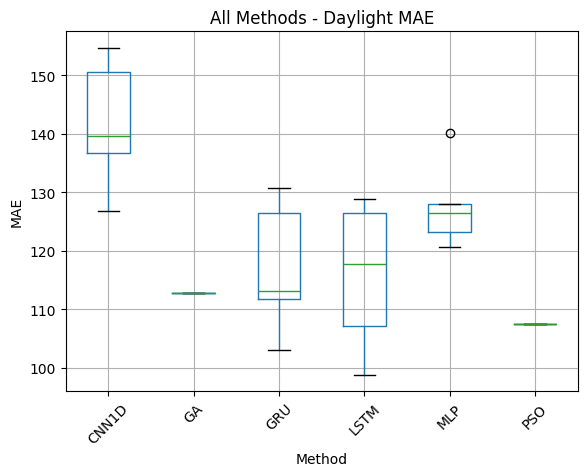

Saved: /home/jovyan/work/outputs/figures/combined_boxplot_mae.png


In [14]:
plt.figure(figsize=(12,5))

combined_df.boxplot(
    column="Daylight_MAE",
    by="Method"
)

plt.title("All Methods - Daylight MAE")
plt.suptitle("")

plt.ylabel("MAE")
plt.xticks(rotation=45)

plt.grid(True)

combined_boxplot_path = os.path.join(
    FIGURES_DIR,
    "combined_boxplot_mae.png"
)

plt.savefig(
    combined_boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", combined_boxplot_path)

In [15]:
best_baseline = baseline_df.sort_values(
    "Daylight_MAE"
).iloc[0]

best_baseline

Model                          LSTM
Seed                              1
Test_MAE                  62.594117
Test_RMSE                108.656055
Test_R2                    0.920777
Daylight_MAE              98.757333
Daylight_RMSE            146.169093
Daylight_R2                0.805795
Training_Time_Seconds    103.141855
Epochs                           19
Name: 11, dtype: object

In [16]:
best_optimized = optimized_df.sort_values(
    "Daylight_MAE"
).iloc[0]

best_optimized

Optimizer                       PSO
Test_MAE                  57.337343
Test_RMSE                111.660989
Test_R2                    0.916335
Daylight_MAE             107.462846
Daylight_RMSE            154.938887
Daylight_R2                0.781792
Training_Time_Seconds     49.626996
Epochs                           20
units_1                          81
units_2                          58
dropout_rate               0.190421
learning_rate              0.003177
batch_size                       64
Name: 0, dtype: object

In [17]:
baseline_groups = []

for model_name in baseline_df["Model"].unique():

    group = baseline_df[
        baseline_df["Model"] == model_name
    ]["Daylight_MAE"].values

    baseline_groups.append(group)

friedman_statistic, friedman_p = friedmanchisquare(
    *baseline_groups
)

print("Friedman statistic:", friedman_statistic)
print("Friedman p-value:", friedman_p)

Friedman statistic: 7.799999999999997
Friedman p-value: 0.05033109785985342


In [18]:
best_baseline_name = best_baseline["Model"]

baseline_best_values = baseline_df[
    baseline_df["Model"] == best_baseline_name
]["Daylight_MAE"].values

optimized_best_values = optimized_df[
    optimized_df["Optimizer"] == best_optimized["Optimizer"]
]["Daylight_MAE"].values

min_len = min(
    len(baseline_best_values),
    len(optimized_best_values)
)

baseline_best_values = baseline_best_values[:min_len]
optimized_best_values = optimized_best_values[:min_len]

wilcoxon_statistic, wilcoxon_p = wilcoxon(
    baseline_best_values,
    optimized_best_values
)

print("Wilcoxon statistic:", wilcoxon_statistic)
print("Wilcoxon p-value:", wilcoxon_p)

Wilcoxon statistic: 0.0
Wilcoxon p-value: 1.0


In [19]:
nemenyi_data = []

for model_name in baseline_df["Model"].unique():

    values = baseline_df[
        baseline_df["Model"] == model_name
    ]["Daylight_MAE"].values

    nemenyi_data.append(values)

nemenyi_matrix = np.array(nemenyi_data).T

nemenyi_df = pd.DataFrame(
    nemenyi_matrix,
    columns=baseline_df["Model"].unique()
)

nemenyi_results = sp.posthoc_nemenyi_friedman(
    nemenyi_df
)

nemenyi_results

,MLP,CNN1D,LSTM,GRU
MLP,1.000000,0.315940,0.760994,0.994838
CNN1D,0.315940,1.000000,0.035525,0.203470
LSTM,0.760994,0.035525,1.000000,0.883087
GRU,0.994838,0.203470,0.883087,1.000000


In [20]:
statistical_results = {

    "friedman_statistic": float(friedman_statistic),
    "friedman_p_value": float(friedman_p),

    "wilcoxon_statistic": float(wilcoxon_statistic),
    "wilcoxon_p_value": float(wilcoxon_p)

}

statistical_results_path = os.path.join(
    RESULTS_DIR,
    "statistical_results.json"
)

with open(statistical_results_path, "w") as f:

    json.dump(
        statistical_results,
        f,
        indent=4
    )

print("Saved:", statistical_results_path)

Saved: /home/jovyan/work/outputs/results/statistical_results.json


In [21]:
nemenyi_results_path = os.path.join(
    TABLES_DIR,
    "nemenyi_results.csv"
)

nemenyi_results.to_csv(
    nemenyi_results_path
)

print("Saved:", nemenyi_results_path)

Saved: /home/jovyan/work/outputs/tables/nemenyi_results.csv


In [22]:
optimization_history_path = os.path.join(
    RESULTS_DIR,
    "optimization_fitness_history.csv"
)

fitness_history_df = pd.read_csv(
    optimization_history_path
)

fitness_history_df.head()

,units_1,units_2,dropout_rate,learning_rate,batch_size,fitness,status
0,68,62,0.319598,0.003033,16,71.324466,ok
1,47,19,0.359853,0.003045,64,66.622227,ok
2,34,63,0.349733,0.001140,32,63.925096,ok
3,50,31,0.257427,0.002217,32,75.654799,ok
4,91,23,0.187643,0.001895,32,77.345621,ok


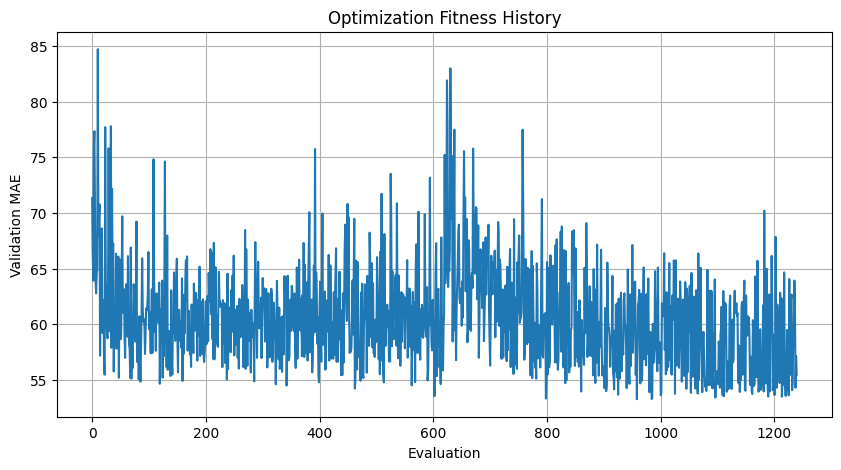

Saved: /home/jovyan/work/outputs/figures/fitness_history.png


In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    fitness_history_df["fitness"].values
)

plt.title("Optimization Fitness History")

plt.xlabel("Evaluation")
plt.ylabel("Validation MAE")

plt.grid(True)

fitness_plot_path = os.path.join(
    FIGURES_DIR,
    "fitness_history.png"
)

plt.savefig(
    fitness_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fitness_plot_path)

In [24]:
baseline_best_mae = best_baseline["Daylight_MAE"]
optimized_best_mae = best_optimized["Daylight_MAE"]

improvement_percentage = (
    (baseline_best_mae - optimized_best_mae)
    / baseline_best_mae
) * 100

print("Best baseline MAE:", baseline_best_mae)
print("Best optimized MAE:", optimized_best_mae)

print("Improvement percentage:", improvement_percentage)

Best baseline MAE: 98.75733303132483
Best optimized MAE: 107.46284608790114
Improvement percentage: -8.815054831234665


In [25]:
improvement_summary = {

    "best_baseline_model": str(best_baseline["Model"]),
    "best_baseline_mae": float(baseline_best_mae),

    "best_optimized_method": str(best_optimized["Optimizer"]),
    "best_optimized_mae": float(optimized_best_mae),

    "improvement_percentage": float(improvement_percentage)

}

improvement_summary_path = os.path.join(
    RESULTS_DIR,
    "improvement_summary.json"
)

with open(improvement_summary_path, "w") as f:

    json.dump(
        improvement_summary,
        f,
        indent=4
    )

print("Saved:", improvement_summary_path)

Saved: /home/jovyan/work/outputs/results/improvement_summary.json


In [26]:
final_comparison = pd.DataFrame({

    "Method": [
        best_baseline["Model"],
        best_optimized["Optimizer"]
    ],

    "Type": [
        "Baseline",
        "Optimized"
    ],

    "Daylight_MAE": [
        best_baseline["Daylight_MAE"],
        best_optimized["Daylight_MAE"]
    ],

    "Daylight_RMSE": [
        best_baseline["Daylight_RMSE"],
        best_optimized["Daylight_RMSE"]
    ],

    "Daylight_R2": [
        best_baseline["Daylight_R2"],
        best_optimized["Daylight_R2"]
    ]

})

final_comparison

,Method,Type,Daylight_MAE,Daylight_RMSE,Daylight_R2
0,LSTM,Baseline,98.757333,146.169093,0.805795
1,PSO,Optimized,107.462846,154.938887,0.781792


In [27]:
final_comparison_path = os.path.join(
    TABLES_DIR,
    "final_comparison.csv"
)

final_comparison.to_csv(
    final_comparison_path,
    index=False
)

print("Saved:", final_comparison_path)

Saved: /home/jovyan/work/outputs/tables/final_comparison.csv


In [28]:
article_table = combined_df.groupby(
    ["Method", "Type"]
).agg({

    "Daylight_MAE": ["mean", "std"]

})

article_table

Daylight_MAE           
                         mean        std
Method Type                             
CNN1D  Baseline    141.631108  11.209182
GA     Optimized   112.801450        NaN
GRU    Baseline    117.052837  11.350561
LSTM   Baseline    115.750315  12.745650
MLP    Baseline    127.639824   7.511102
PSO    Optimized   107.462846        NaN

In [29]:
article_table_path = os.path.join(
    TABLES_DIR,
    "article_metrics_table.csv"
)

article_table.to_csv(
    article_table_path
)

print("Saved:", article_table_path)

Saved: /home/jovyan/work/outputs/tables/article_metrics_table.csv


In [30]:
print("===================================")
print("FINAL ANALYSIS SUMMARY")
print("===================================")

print("\nBest baseline model:")
print(best_baseline)

print("\nBest optimized model:")
print(best_optimized)

print("\nImprovement percentage:")
print(improvement_percentage)

print("\nFriedman p-value:")
print(friedman_p)

print("\nWilcoxon p-value:")
print(wilcoxon_p)

print("\nAnalysis completed.")

FINAL ANALYSIS SUMMARY

Best baseline model:
Model                          LSTM
Seed                              1
Test_MAE                  62.594117
Test_RMSE                108.656055
Test_R2                    0.920777
Daylight_MAE              98.757333
Daylight_RMSE            146.169093
Daylight_R2                0.805795
Training_Time_Seconds    103.141855
Epochs                           19
Name: 11, dtype: object

Best optimized model:
Optimizer                       PSO
Test_MAE                  57.337343
Test_RMSE                111.660989
Test_R2                    0.916335
Daylight_MAE             107.462846
Daylight_RMSE            154.938887
Daylight_R2                0.781792
Training_Time_Seconds     49.626996
Epochs                           20
units_1                          81
units_2                          58
dropout_rate               0.190421
learning_rate              0.003177
batch_size                       64
Name: 0, dtype: object

Improvement percenta